In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install segyio numpy matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 4.0 MB/s eta 0:00:00


In [ ]:
import os

# Укажи путь к твоему файлу на Google Диске
# (найди путь: нажми на файле правой кнопкой в Google Drive → "Поделиться" → скопируй путь)
file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

# Проверяем, существует ли файл
if os.path.exists(file_path):
    print("Файл найден!")
    # Выводим размер файла
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Размер файла: {size:.2f} МБ")
else:
    print("Файл не найден. Проверь путь.")

Файл найден!
Размер файла: 1876.19 МБ


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import segyio
import os
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ------------------------------------------------------------------------------
# Параметры
# ------------------------------------------------------------------------------
file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'
n_traces_to_use = 700      # количество трасс
n_lags = 31                 # количество лагов автокорреляции
prominence_factor = 0.3     # чувствительность выделения разломов
min_distance = 15           # минимальное расстояние между разломами (в трассах)
vertical_margin = 10        # отступ от краёв зоны разлома (в отсчётах)
# ------------------------------------------------------------------------------

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Файл не найден: {file_path}")

print("Загрузка данных...")
with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size
    print(f"Всего трасс в файле: {n_traces_total}")
    print(f"Количество отсчётов на трассу: {n_samples}")

    # Берём ПЕРВЫЕ n_traces_to_use трасс
    actual_traces = min(n_traces_to_use, n_traces_total)
    print(f"Загружаем первые {actual_traces} трасс")

    data = np.zeros((actual_traces, n_samples), dtype=np.float32)
    for i in range(actual_traces):
        data[i, :] = segyfile.trace[i]
        if i % 100 == 0 and i > 0:
            print(f"  Загружено трасс: {i+1}/{actual_traces}")

# Транспонируем: (время, трассы)
seismic = data.T
n_samples, n_traces = seismic.shape
print(f"\nРазмер разреза: {n_samples} отсчётов (время) × {n_traces} трасс")

# =============================================================================
# ФУНКЦИИ МЕТОДА PCA (ГЛАВА 2.2)
# =============================================================================

def autocorrelation(trace, n_lags):
    """
    Автокорреляционная функция трассы.
    По методике Приезжева и др. (2025)
    """
    trace_centered = trace - np.mean(trace)
    acf = np.correlate(trace_centered, trace_centered, mode='full')
    center = len(acf) // 2
    half = n_lags // 2
    acf = acf[center - half : center + half + 1]
    if acf[half] != 0:
        acf = acf / acf[half]
    return acf

def compute_pca(seismic, n_lags):
    """
    Выполняет PCA-разложение автокорреляционных функций трасс.
    Возвращает PCA-компоненты, собственные значения и матрицу автокорреляций.
    """
    n_traces = seismic.shape[1]

    print("\nРасчёт автокорреляционных функций...")
    acf_matrix = np.zeros((n_traces, n_lags))
    for i in range(n_traces):
        acf_matrix[i, :] = autocorrelation(seismic[:, i], n_lags)
        if i % 100 == 0:
            print(f"  Обработано трасс: {i+1}/{n_traces}")

    print("Выполнение PCA-разложения...")
    acf_centered = acf_matrix - np.mean(acf_matrix, axis=0)
    cov_matrix = np.cov(acf_centered.T)
    eigenvalues, eigenvectors = eigh(cov_matrix)

    # Сортируем по убыванию собственных значений
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Проекция на компоненты
    n_components = 5
    pca_components = np.zeros((n_traces, n_components))
    for i in range(n_components):
        pca_components[:, i] = acf_centered @ eigenvectors[:, i]

    return pca_components, eigenvalues, acf_matrix

def create_pca_color_section(seismic, pca_components):
    """
    Создаёт цветной PCA-разрез (RGB по первым трём компонентам).
    """
    n_samples, n_traces = seismic.shape

    def normalize(data):
        vmin = np.percentile(data, 2)
        vmax = np.percentile(data, 98)
        if vmax - vmin < 1e-9:
            return np.zeros_like(data)
        return np.clip((data - vmin) / (vmax - vmin), 0, 1)

    colored = np.zeros((n_samples, n_traces, 3))
    for i in range(n_traces):
        colored[:, i, 0] = seismic[:, i] * normalize(pca_components[:, 0])[i]
        colored[:, i, 1] = seismic[:, i] * normalize(pca_components[:, 1])[i]
        colored[:, i, 2] = seismic[:, i] * normalize(pca_components[:, 2])[i]

    for c in range(3):
        colored[:, :, c] = normalize(colored[:, :, c])

    return colored

def detect_faults_from_pca(pca_components, prominence_factor=0.3, min_distance=15):
    """
    Выделяет разломы по пикам в 1-й PCA компоненте.
    """
    component = pca_components[:, 0]
    smoothed = gaussian_filter1d(component, sigma=5)
    norm = (smoothed - np.min(smoothed)) / (np.max(smoothed) - np.min(smoothed))
    percentile_threshold = np.percentile(norm, 85)
    dynamic_threshold = np.mean(norm) + prominence_factor * np.std(norm)
    threshold = max(percentile_threshold, dynamic_threshold)
    peaks, _ = find_peaks(norm, height=threshold, distance=min_distance)
    return peaks, norm, threshold, component, smoothed

def get_fault_vertical_zone(seismic, trace_idx, margin=15):
    """
    Определяет вертикальный интервал, где находится разлом.
    Использует градиент амплитуд.
    """
    gradient = np.abs(np.gradient(seismic[:, trace_idx]))
    gradient_smooth = gaussian_filter1d(gradient, sigma=3)
    threshold = np.percentile(gradient_smooth, 80)
    above = gradient_smooth > threshold

    from scipy.ndimage import label
    labeled, num = label(above)

    max_len = 0
    best_region = None
    for region in range(1, num + 1):
        indices = np.where(labeled == region)[0]
        if len(indices) > max_len:
            max_len = len(indices)
            best_region = indices

    if best_region is not None and len(best_region) > 10:
        top = max(0, best_region[0] - margin)
        bottom = min(seismic.shape[0] - 1, best_region[-1] + margin)
    else:
        top = 0
        bottom = seismic.shape[0] - 1

    return top, bottom

# =============================================================================
# ВЫПОЛНЕНИЕ PCA-АНАЛИЗА
# =============================================================================
print("\n" + "="*70)
print("МЕТОД ОРТОГОНАЛЬНОГО РАЗЛОЖЕНИЯ (PCA) - ГЛАВА 2.2")
print("По методике Приезжева и др. (2025)")
print("="*70)

# Выполняем PCA
pca_components, eigenvalues, acf_matrix = compute_pca(seismic, n_lags)

# Выводим энергию компонент
print(f"\nЭнергия PCA компонент (ранжирована по убыванию):")
for i in range(5):
    energy_percent = eigenvalues[i] / eigenvalues[0] * 100
    print(f"  Компонента {i+1}: {energy_percent:.1f}% энергии")

# Создаём цветной PCA-разрез
colored_pca = create_pca_color_section(seismic, pca_components)

# Выделяем разломы по 1-й компоненте
peaks, norm, threshold, comp1, comp1_smooth = detect_faults_from_pca(
    pca_components, prominence_factor, min_distance
)

print(f"\nАвтоматическое выделение разломов по 1-й PCA компоненте:")
print(f"  Найдено разломов: {len(peaks)}")
if len(peaks) > 0:
    print(f"  Положение разломов (трассы): {peaks}")

# Определяем вертикальные зоны для каждого разлома
fault_zones = []
for trace in peaks:
    top, bottom = get_fault_vertical_zone(seismic, trace, margin=vertical_margin)
    fault_zones.append({
        'trace': trace,
        'top': top,
        'bottom': bottom,
        'length': bottom - top,
        'intensity': comp1[trace]
    })
    print(f"  Разлом на трассе {trace}: зона отсчёты {top}-{bottom} (протяжённость {bottom-top} отсчётов)")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Исходный разрез
ax1 = axes[0, 0]
im1 = ax1.imshow(seismic, cmap='seismic', aspect='auto',
                 vmin=-np.percentile(np.abs(seismic), 95),
                 vmax=np.percentile(np.abs(seismic), 95))
ax1.set_title(f'Исходный сейсмический разрез (первые {n_traces} трасс)', fontsize=12)
ax1.set_xlabel('Номер трассы')
ax1.set_ylabel('Время (отсчёты)')
plt.colorbar(im1, ax=ax1, label='Амплитуда')

# 2. 1-я PCA компонента с выделенными разломами
ax2 = axes[0, 1]
ax2.plot(comp1, color='darkred', linewidth=1, alpha=0.7, label='1-я компонента (исходная)')
ax2.plot(comp1_smooth, color='red', linewidth=1.5, label='1-я компонента (сглаженная)')
ax2.axhline(y=threshold * np.max(comp1), color='green', linestyle='--', alpha=0.7,
            label=f'Порог ({threshold:.2f} норм.)')
if len(peaks) > 0:
    ax2.scatter(peaks, comp1[peaks], color='red', s=100, zorder=5,
                marker='v', edgecolors='black', linewidth=1.5,
                label=f'Разломы ({len(peaks)})')
ax2.set_title('1-я PCA компонента (разломы = пики амплитуды)', fontsize=12)
ax2.set_xlabel('Номер трассы')
ax2.set_ylabel('Амплитуда')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. PCA-цветной разрез (RGB по трём компонентам)
ax3 = axes[1, 0]
ax3.imshow(colored_pca, aspect='auto')
ax3.set_title('PCA-разрез (RGB: 1-я, 2-я, 3-я компоненты)', fontsize=12)
ax3.set_xlabel('Номер трассы')
ax3.set_ylabel('Время (отсчёты)')

# 4. PCA-разрез с локальной подсветкой разломов
ax4 = axes[1, 1]
ax4.imshow(colored_pca, aspect='auto')

for fault in fault_zones:
    trace = fault['trace']
    top = fault['top']
    bottom = fault['bottom']

    # Рисуем линию ТОЛЬКО в зоне разлома
    ax4.plot([trace, trace], [top, bottom], color='red', linewidth=3, alpha=0.9)

    # Подпись рядом с зоной разлома
    ax4.text(trace + 3, top, f'F',
             color='red', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax4.set_title(f'PCA-разрез с локальным выделением разломов\n(найдено: {len(fault_zones)})', fontsize=12)
ax4.set_xlabel('Номер трассы')
ax4.set_ylabel('Время (отсчёты)')

plt.tight_layout()
plt.show()

# =============================================================================
# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: исходный разрез с подсветкой разломов
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(seismic, cmap='gray', aspect='auto',
          vmin=-np.percentile(np.abs(seismic), 95),
          vmax=np.percentile(np.abs(seismic), 95))

for i, fault in enumerate(fault_zones):
    trace = fault['trace']
    top = fault['top']
    bottom = fault['bottom']

    # Рисуем линию ТОЛЬКО в зоне разлома
    ax.plot([trace, trace], [top, bottom], color='red', linewidth=3, alpha=0.9)

    # Подпись
    ax.text(trace + 3, top, f'Разлом {i+1}',
            color='red', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'Исходный разрез с локальным выделением разломов\n(первые {n_traces} трасс, найдено: {len(fault_zones)})', fontsize=12)
ax.set_xlabel('Номер трассы')
ax.set_ylabel('Время (отсчёты)')

plt.tight_layout()
plt.show()

# =============================================================================
# ГРАФИКИ ОТДЕЛЬНЫХ PCA КОМПОНЕНТ
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

colors = ['red', 'green', 'blue']
titles = ['1-я компонента (максимальная энергия)',
          '2-я компонента',
          '3-я компонента']

for i, (ax, color, title) in enumerate(zip(axes, colors, titles)):
    ax.plot(pca_components[:, i], color=color, linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Номер трассы')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.3)

    # Если это 1-я компонента, отмечаем разломы
    if i == 0 and len(peaks) > 0:
        ax.scatter(peaks, pca_components[peaks, i], color='red', s=80,
                   marker='v', edgecolors='black', zorder=5,
                   label=f'Разломы ({len(peaks)})')
        ax.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# ИТОГОВЫЙ ОТЧЁТ
# =============================================================================
print("\n" + "="*80)
print("ИТОГОВЫЙ ОТЧЁТ ПО МЕТОДУ PCA (ГЛАВА 2.2)")
print("="*80)

print(f"\n{'Параметр':<35} {'Значение':<25}")
print("-"*60)
print(f"{'Количество трасс':<35} {n_traces:<25}")
print(f"{'Количество отсчётов на трассу':<35} {n_samples:<25}")
print(f"{'Количество лагов автокорреляции':<35} {n_lags:<25}")
print(f"{'Чувствительность выделения разломов':<35} {prominence_factor:<25}")
print(f"{'Мин. расстояние между разломами':<35} {min_distance:<25}")

print(f"\nЭнергия PCA компонент:")
for i in range(3):
    print(f"  Компонента {i+1}: {eigenvalues[i]/eigenvalues[0]*100:.1f}% энергии")

print(f"\nРезультат выделения разломов:")
print(f"  Найдено разломов: {len(fault_zones)}")

if len(fault_zones) > 0:
    print(f"\nДетальная информация о разломах:")
    for i, fault in enumerate(fault_zones):
        print(f"\n  Разлом {i+1}:")
        print(f"    Трасса: {fault['trace']}")
        print(f"    Вертикальный интервал: отсчёты {fault['top']} - {fault['bottom']}")
        print(f"    Протяжённость: {fault['length']} отсчётов")
        print(f"    Интенсивность (амплитуда 1-й компоненты): {fault['intensity']:.4f}")
else:
    print(f"\n  Разломы не выявлены. Возможные причины:")
    print(f"    - Метод PCA из главы 2.2 предназначен для выделения стратиграфических объектов")
    print(f"    - Разломы могут проявляться в других компонентах (проверьте графики)")
    print(f"    - Попробуйте уменьшить prominence_factor (например, до 0.2)")

print("\n" + "="*80)
print("ВЫВОД ДЛЯ КУРСОВОЙ РАБОТЫ:")
print("="*80)
print("Метод ортогонального разложения (PCA) на автокорреляционных функциях")
print("позволяет:")
print("  - Разложить волновое поле на ортогональные компоненты, ранжированные по энергии")
print("  - Создать RGB-изображение для визуализации линеаментов")
print("  - Выявить стратиграфические неоднородности и цветовые аномалии")
print("\nДля картирования разломов данный метод менее эффективен, чем:")
print("  - Атрибут когерентности (глава 2.4)")
print("  - Атрибуты кривизны (глава 2.3)")
print("  - Дифрагированные волны (глава 2.1)")
print("="*80)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import segyio
import os
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ------------------------------------------------------------------------------
# Параметры
# ------------------------------------------------------------------------------
file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'
n_traces_to_use = 700      # количество трасс
n_lags = 31                 # количество лагов автокорреляции
prominence_factor = 0.3     # чувствительность выделения линеаментов (аномалий)
min_distance = 15           # минимальное расстояние между линеаментами (в трассах)
vertical_margin = 10        # отступ от краёв зоны аномалии (в отсчётах)
# ------------------------------------------------------------------------------

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Файл не найден: {file_path}")

print("Загрузка данных...")
with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size
    print(f"Всего трасс в файле: {n_traces_total}")
    print(f"Количество отсчётов на трассу: {n_samples}")

    # Берём ПЕРВЫЕ n_traces_to_use трасс
    actual_traces = min(n_traces_to_use, n_traces_total)
    print(f"Загружаем первые {actual_traces} трасс")

    data = np.zeros((actual_traces, n_samples), dtype=np.float32)
    for i in range(actual_traces):
        data[i, :] = segyfile.trace[i]
        if i % 100 == 0 and i > 0:
            print(f"  Загружено трасс: {i+1}/{actual_traces}")

# Транспонируем: (время, трассы)
seismic = data.T
n_samples, n_traces = seismic.shape
print(f"\nРазмер разреза: {n_samples} отсчётов (время) × {n_traces} трасс")

# =============================================================================
# ФУНКЦИИ МЕТОДА PCA (ГЛАВА 2.2)
# =============================================================================

def autocorrelation(trace, n_lags):
    """
    Автокорреляционная функция трассы.
    По методике Приезжева и др. (2025)
    """
    trace_centered = trace - np.mean(trace)
    acf = np.correlate(trace_centered, trace_centered, mode='full')
    center = len(acf) // 2
    half = n_lags // 2
    acf = acf[center - half : center + half + 1]
    if acf[half] != 0:
        acf = acf / acf[half]
    return acf

def compute_pca(seismic, n_lags):
    """
    Выполняет PCA-разложение автокорреляционных функций трасс.
    Возвращает PCA-компоненты, собственные значения и матрицу автокорреляций.
    """
    n_traces = seismic.shape[1]

    print("\nРасчёт автокорреляционных функций...")
    acf_matrix = np.zeros((n_traces, n_lags))
    for i in range(n_traces):
        acf_matrix[i, :] = autocorrelation(seismic[:, i], n_lags)
        if i % 100 == 0:
            print(f"  Обработано трасс: {i+1}/{n_traces}")

    print("Выполнение PCA-разложения...")
    acf_centered = acf_matrix - np.mean(acf_matrix, axis=0)
    cov_matrix = np.cov(acf_centered.T)
    eigenvalues, eigenvectors = eigh(cov_matrix)

    # Сортируем по убыванию собственных значений
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Проекция на компоненты
    n_components = 5
    pca_components = np.zeros((n_traces, n_components))
    for i in range(n_components):
        pca_components[:, i] = acf_centered @ eigenvectors[:, i]

    return pca_components, eigenvalues, acf_matrix

def create_pca_color_section(pca_components):
    """
    Создаёт цветной PCA-разрез (RGB по первым трём компонентам).
    ИСПРАВЛЕНО: теперь используются только значения главных компонент, без перемножения с исходными данными.
    """
    n_traces = pca_components.shape[0]

    def normalize(data):
        vmin = np.percentile(data, 2)
        vmax = np.percentile(data, 98)
        if vmax - vmin < 1e-9:
            return np.zeros_like(data)
        return np.clip((data - vmin) / (vmax - vmin), 0, 1)

    # Для визуализации нам нужна матрица размером (время, трассы, 3)
    # Но наши PCA-компоненты определены на трассах, а не на времени.
    # Создадим изображение, где по горизонтали - номер трассы, а по вертикали - номер отсчета.
    # Значение RGB на каждом пикселе будет определяться значением компоненты для этой трассы,
    # повторенным для всех временных отсчетов.
    colored = np.zeros((n_samples, n_traces, 3))
    for i in range(3): # Берем первые три компоненты для RGB
        # Нормализуем компоненту
        norm_component = normalize(pca_components[:, i])
        # Размножаем на все временные отсчеты (каждый столбец имеет постоянное значение)
        colored[:, :, i] = np.tile(norm_component, (n_samples, 1))

    return colored

def detect_anomalies_from_pca(pca_components, prominence_factor=0.3, min_distance=15):
    """
    Выделяет аномальные зоны (линеаменты) по пикам в 1-й PCA компоненте.
    ИСПРАВЛЕНО: изменено название функции, чтобы отразить ее истинное назначение.
    """
    component = pca_components[:, 0]
    smoothed = gaussian_filter1d(component, sigma=5)
    norm = (smoothed - np.min(smoothed)) / (np.max(smoothed) - np.min(smoothed))
    percentile_threshold = np.percentile(norm, 85)
    dynamic_threshold = np.mean(norm) + prominence_factor * np.std(norm)
    threshold = max(percentile_threshold, dynamic_threshold)
    peaks, _ = find_peaks(norm, height=threshold, distance=min_distance)
    return peaks, norm, threshold, component, smoothed

# Функция get_fault_vertical_zone пока остается без изменений, но важно помнить о ее ограничениях.
def get_fault_vertical_zone(seismic, trace_idx, margin=15):
    """
    Определяет вертикальный интервал, где предположительно находится разлом.
    Использует градиент амплитуд на указанной трассе.
    """
    gradient = np.abs(np.gradient(seismic[:, trace_idx]))
    gradient_smooth = gaussian_filter1d(gradient, sigma=3)
    threshold = np.percentile(gradient_smooth, 80)
    above = gradient_smooth > threshold

    from scipy.ndimage import label
    labeled, num = label(above)

    max_len = 0
    best_region = None
    for region in range(1, num + 1):
        indices = np.where(labeled == region)[0]
        if len(indices) > max_len:
            max_len = len(indices)
            best_region = indices

    if best_region is not None and len(best_region) > 10:
        top = max(0, best_region[0] - margin)
        bottom = min(seismic.shape[0] - 1, best_region[-1] + margin)
    else:
        top = 0
        bottom = seismic.shape[0] - 1

    return top, bottom

# =============================================================================
# ВЫПОЛНЕНИЕ PCA-АНАЛИЗА
# =============================================================================
print("\n" + "="*70)
print("МЕТОД ОРТОГОНАЛЬНОГО РАЗЛОЖЕНИЯ (PCA) - ГЛАВА 2.2")
print("По методике Приезжева и др. (2025)")
print("="*70)

# Выполняем PCA
pca_components, eigenvalues, acf_matrix = compute_pca(seismic, n_lags)

# Выводим энергию компонент
print(f"\nЭнергия PCA компонент (ранжирована по убыванию):")
for i in range(5):
    energy_percent = eigenvalues[i] / eigenvalues[0] * 100
    print(f"  Компонента {i+1}: {energy_percent:.1f}% энергии")

# Создаём цветной PCA-разрез (ИСПРАВЛЕНО: используется новая функция)
colored_pca = create_pca_color_section(pca_components)

# Выделяем аномалии (потенциальные разломы) по 1-й компоненте
peaks, norm, threshold, comp1, comp1_smooth = detect_anomalies_from_pca(
    pca_components, prominence_factor, min_distance
)

print(f"\nАвтоматическое выделение аномалий (потенциальных разломов) по 1-й PCA компоненте:")
print(f"  Найдено аномалий: {len(peaks)}")
if len(peaks) > 0:
    print(f"  Положение аномалий (трассы): {peaks}")

# Определяем вертикальные зоны для каждой аномалии (используем существующую функцию)
anomaly_zones = []
for trace in peaks:
    top, bottom = get_fault_vertical_zone(seismic, trace, margin=vertical_margin)
    anomaly_zones.append({
        'trace': trace,
        'top': top,
        'bottom': bottom,
        'length': bottom - top,
        'intensity': comp1[trace]
    })
    print(f"  Аномалия на трассе {trace}: зона отсчёты {top}-{bottom} (протяжённость {bottom-top} отсчётов)")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Исходный разрез
ax1 = axes[0, 0]
im1 = ax1.imshow(seismic, cmap='seismic', aspect='auto',
                 vmin=-np.percentile(np.abs(seismic), 95),
                 vmax=np.percentile(np.abs(seismic), 95))
ax1.set_title(f'Исходный сейсмический разрез (первые {n_traces} трасс)', fontsize=12)
ax1.set_xlabel('Номер трассы')
ax1.set_ylabel('Время (отсчёты)')
plt.colorbar(im1, ax=ax1, label='Амплитуда')

# 2. 1-я PCA компонента с выделенными аномалиями
ax2 = axes[0, 1]
ax2.plot(comp1, color='darkred', linewidth=1, alpha=0.7, label='1-я компонента (исходная)')
ax2.plot(comp1_smooth, color='red', linewidth=1.5, label='1-я компонента (сглаженная)')
ax2.axhline(y=threshold * np.max(comp1), color='green', linestyle='--', alpha=0.7,
            label=f'Порог ({threshold:.2f} норм.)')
if len(peaks) > 0:
    ax2.scatter(peaks, comp1[peaks], color='red', s=100, zorder=5,
                marker='v', edgecolors='black', linewidth=1.5,
                label=f'Аномалии ({len(peaks)})')
ax2.set_title('1-я PCA компонента (аномалии = пики амплитуды)', fontsize=12)
ax2.set_xlabel('Номер трассы')
ax2.set_ylabel('Амплитуда')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. PCA-цветной разрез (RGB по трём компонентам) - ИСПРАВЛЕНО
ax3 = axes[1, 0]
ax3.imshow(colored_pca, aspect='auto')
ax3.set_title('PCA-разрез (RGB: 1-я, 2-я, 3-я компоненты)', fontsize=12)
ax3.set_xlabel('Номер трассы')
ax3.set_ylabel('Время (отсчёты)')

# 4. PCA-разрез с локальной подсветкой аномалий
ax4 = axes[1, 1]
ax4.imshow(colored_pca, aspect='auto')

for anomaly in anomaly_zones:
    trace = anomaly['trace']
    top = anomaly['top']
    bottom = anomaly['bottom']

    # Рисуем линию ТОЛЬКО в зоне аномалии
    ax4.plot([trace, trace], [top, bottom], color='red', linewidth=3, alpha=0.9)

    # Подпись рядом с зоной аномалии
    ax4.text(trace + 3, top, f'A', # Меняем 'F' на 'A' (Anomaly)
             color='red', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax4.set_title(f'PCA-разрез с локальным выделением аномалий\n(найдено: {len(anomaly_zones)})', fontsize=12)
ax4.set_xlabel('Номер трассы')
ax4.set_ylabel('Время (отсчёты)')

plt.tight_layout()
plt.show()

# =============================================================================
# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: исходный разрез с подсветкой аномалий
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(seismic, cmap='gray', aspect='auto',
          vmin=-np.percentile(np.abs(seismic), 95),
          vmax=np.percentile(np.abs(seismic), 95))

for i, anomaly in enumerate(anomaly_zones):
    trace = anomaly['trace']
    top = anomaly['top']
    bottom = anomaly['bottom']

    # Рисуем линию ТОЛЬКО в зоне аномалии
    ax.plot([trace, trace], [top, bottom], color='red', linewidth=3, alpha=0.9)

    # Подпись
    ax.text(trace + 3, top, f'Аномалия {i+1}', # Меняем "Разлом" на "Аномалия"
            color='red', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'Исходный разрез с локальным выделением аномалий\n(первые {n_traces} трасс, найдено: {len(anomaly_zones)})', fontsize=12)
ax.set_xlabel('Номер трассы')
ax.set_ylabel('Время (отсчёты)')

plt.tight_layout()
plt.show()

# =============================================================================
# ГРАФИКИ ОТДЕЛЬНЫХ PCA КОМПОНЕНТ
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

colors = ['red', 'green', 'blue']
titles = ['1-я компонента (максимальная энергия)',
          '2-я компонента',
          '3-я компонента']

for i, (ax, color, title) in enumerate(zip(axes, colors, titles)):
    ax.plot(pca_components[:, i], color=color, linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Номер трассы')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.3)

    # Если это 1-я компонента, отмечаем аномалии
    if i == 0 and len(peaks) > 0:
        ax.scatter(peaks, pca_components[peaks, i], color='red', s=80,
                   marker='v', edgecolors='black', zorder=5,
                   label=f'Аномалии ({len(peaks)})')
        ax.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# ИТОГОВЫЙ ОТЧЁТ
# =============================================================================
print("\n" + "="*80)
print("ИТОГОВЫЙ ОТЧЁТ ПО МЕТОДУ PCA (ГЛАВА 2.2)")
print("="*80)

print(f"\n{'Параметр':<35} {'Значение':<25}")
print("-"*60)
print(f"{'Количество трасс':<35} {n_traces:<25}")
print(f"{'Количество отсчётов на трассу':<35} {n_samples:<25}")
print(f"{'Количество лагов автокорреляции':<35} {n_lags:<25}")
print(f"{'Чувствительность выделения аномалий':<35} {prominence_factor:<25}")
print(f"{'Мин. расстояние между аномалиями':<35} {min_distance:<25}")

print(f"\nЭнергия PCA компонент:")
for i in range(3):
    print(f"  Компонента {i+1}: {eigenvalues[i]/eigenvalues[0]*100:.1f}% энергии")

print(f"\nРезультат выделения аномалий (потенциальных разломов):")
print(f"  Найдено аномалий: {len(anomaly_zones)}")

if len(anomaly_zones) > 0:
    print(f"\nДетальная информация об аномалиях:")
    for i, anomaly in enumerate(anomaly_zones):
        print(f"\n  Аномалия {i+1}:")
        print(f"    Трасса: {anomaly['trace']}")
        print(f"    Вертикальный интервал: отсчёты {anomaly['top']} - {anomaly['bottom']}")
        print(f"    Протяжённость: {anomaly['length']} отсчётов")
        print(f"    Интенсивность (амплитуда 1-й компоненты): {anomaly['intensity']:.4f}")
else:
    print(f"\n  Аномалии не выявлены. Возможные причины:")
    print(f"    - Метод PCA из главы 2.2 предназначен для выделения стратиграфических объектов")
    print(f"    - Аномалии, связанные с разломами, могут проявляться в других компонентах (проверьте графики)")
    print(f"    - Попробуйте уменьшить prominence_factor (например, до 0.2)")

print("\n" + "="*80)
print("ВЫВОД ДЛЯ КУРСОВОЙ РАБОТЫ:")
print("="*80)
print("Метод ортогонального разложения (PCA) на автокорреляционных функциях")
print("позволяет:")
print("  - Разложить волновое поле на ортогональные компоненты, ранжированные по энергии")
print("  - Создать RGB-изображение для визуализации линеаментов и стратиграфических неоднородностей")
print("  - Выявить зоны, потенциально связанные с разломами, по аномалиям в первых главных компонентах")
print("\nДля более точного картирования разломов данный метод следует комбинировать с:")
print("  - Атрибутом когерентности (глава 2.4)")
print("  - Атрибутами кривизны (глава 2.3)")
print("  - Анализом дифрагированных волн (глава 2.1)")
print("="*80)

In [ ]:
# Установка необходимых библиотек
!pip install segyio numpy matplotlib scipy

# После установки импортируем всё
import numpy as np
import matplotlib.pyplot as plt
import segyio
import os
from scipy.ndimage import gaussian_filter, sobel


print("Все библиотеки успешно загружены!")

Все библиотеки успешно загружены!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import segyio
import os
from scipy.ndimage import gaussian_filter


# ------------------------------------------------------------------------------
# Параметры
# ------------------------------------------------------------------------------
file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

# Параметры временного среза
time_slice_ms = 500        # время в миллисекундах (или номер отсчёта)
n_inline_to_use = 700      # сколько инлайнов взять
n_crossline_to_use = 700   # сколько кросслайнов взять

# Параметры для обработки
method = 'pca'             # 'pca' или 'fft' (частотная декомпозиция)
# ------------------------------------------------------------------------------

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Файл не найден: {file_path}")

print("="*70)
print("АНАЛИЗ ГОРИЗОНТАЛЬНОГО (ВРЕМЕННОГО) СРЕЗА")
print("Для выделения палеорусел и каналов")
print("="*70)

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ И ОПРЕДЕЛЕНИЕ ГЕОМЕТРИИ КУБА
# =============================================================================
print("\nЗагрузка геометрии куба...")

with segyio.open(file_path, "r", ignore_geometry=False) as segyfile:
    # Пытаемся получить геометрию
    try:
        inlines = segyfile.iline[:]
        crosslines = segyfile.xline[:]
        unique_inlines = np.unique(inlines)
        unique_crosslines = np.unique(crosslines)

        n_inline_total = len(unique_inlines)
        n_crossline_total = len(unique_crosslines)
        n_samples = segyfile.trace[0].size

        print(f"  Инлайнов: {n_inline_total}")
        print(f"  Кросслайнов: {n_crossline_total}")
        print(f"  Отсчётов на трассу: {n_samples}")

        # Создаём словарь для быстрого доступа: (inline, crossline) -> индекс трассы
        trace_index = {}
        for idx, (il, xl) in enumerate(zip(inlines, crosslines)):
            trace_index[(il, xl)] = idx

        # Выбираем подмножество инлайнов и кросслайнов
        n_inline = min(n_inline_to_use, n_inline_total)
        n_crossline = min(n_crossline_to_use, n_crossline_total)

        inline_subset = unique_inlines[:n_inline]
        crossline_subset = unique_crosslines[:n_crossline]

        # Определяем номер временного отсчёта
        # (если time_slice_ms в мс, нужно знать интервал дискретизации)
        dt = segyfile.bin[segyio.BinField.Interval] / 1000  # интервал в мс
        time_index = int(time_slice_ms / dt)
        time_index = min(time_index, n_samples - 1)

        print(f"\n  Выбран временной срез: {time_slice_ms} мс (отсчёт {time_index})")
        print(f"  Размер среза: {n_inline} инлайнов × {n_crossline} кросслайнов")

        # Загружаем временной срез
        print("\nЗагрузка временного среза...")
        time_slice = np.zeros((n_inline, n_crossline), dtype=np.float32)

        for i, il in enumerate(inline_subset):
            for j, xl in enumerate(crossline_subset):
                key = (il, xl)
                if key in trace_index:
                    trace_idx = trace_index[key]
                    time_slice[i, j] = segyfile.trace[trace_idx][time_index]
            if i % 100 == 0:
                print(f"  Загружено инлайнов: {i+1}/{n_inline}")

        print(f"\n  Размер временного среза: {time_slice.shape}")

    except Exception as e:
        print(f"  Не удалось определить геометрию: {e}")
        print("  Пытаемся загрузить как 2D профиль...")

        # Если геометрия не читается, загружаем как 2D
        with segyio.open(file_path, "r", ignore_geometry=True) as segyfile2:
            n_traces = len(segyfile2.trace)
            n_samples = segyfile2.trace[0].size

            # Пытаемся найти квадратную сетку
            n = int(np.sqrt(n_traces))
            if n * n == n_traces:
                n_inline = min(n, n_inline_to_use)
                n_crossline = min(n, n_crossline_to_use)
            else:
                n_inline = min(n_inline_to_use, n_traces)
                n_crossline = min(n_crossline_to_use, n_traces // n_inline)

            time_index = min(time_slice_ms, n_samples - 1)

            time_slice = np.zeros((n_inline, n_crossline), dtype=np.float32)
            for i in range(n_inline):
                for j in range(n_crossline):
                    trace_idx = i * n_crossline + j
                    if trace_idx < n_traces:
                        time_slice[i, j] = segyfile2.trace[trace_idx][time_index]

            print(f"  Размер временного среза (эвристика): {time_slice.shape}")

# =============================================================================
# 2. ОБРАБОТКА ВРЕМЕННОГО СРЕЗА
# =============================================================================

def normalize(data):
    """Нормализация в диапазон [0,1] с отсечением выбросов"""
    vmin = np.percentile(data, 2)
    vmax = np.percentile(data, 98)
    if vmax - vmin < 1e-9:
        return np.zeros_like(data)
    return np.clip((data - vmin) / (vmax - vmin), 0, 1)

def fft_filter_2d(image, low_cut, high_cut, smooth=0.02):
    """2D БПФ фильтрация (частотная декомпозиция)"""
    fft = np.fft.fft2(image)
    fft_shift = np.fft.fftshift(fft)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - ccol)**2 + (Y - crow)**2) / max(crow, ccol)
    freq_norm = dist / np.sqrt(2) * 0.5

    mask = np.exp(- ((freq_norm - low_cut)**2) / (2 * smooth**2)) - \
           np.exp(- ((freq_norm - high_cut)**2) / (2 * smooth**2))
    mask = np.clip(mask, 0, 1)

    filtered_shift = fft_shift * mask
    filtered = np.fft.ifft2(np.fft.ifftshift(filtered_shift))
    return np.real(filtered)

if method == 'pca':
    print("\n" + "="*50)
    print("МЕТОД: PCA-разложение (глава 2.2)")
    print("="*50)

    # Для временного среза делаем PCA по строкам или столбцам
    # Вариант: разворачиваем срез в одномерный массив и делаем PCA

    # Нормализуем срез
    time_slice_norm = normalize(time_slice)

    # Простое RGB-смешивание: используем сам срез и его производные
    # (аналог цветового смешивания для выявления линеаментов)

    # Вычисляем градиенты (для выделения краёв каналов)
    grad_x = np.gradient(time_slice_norm, axis=1)
    grad_y = np.gradient(time_slice_norm, axis=0)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Сглаженная версия (для фона)
    smoothed = gaussian_filter(time_slice_norm, sigma=5)

    # Создаём RGB: R = оригинал, G = градиент, B = сглаженный
    R = time_slice_norm
    G = normalize(grad_magnitude)
    B = smoothed

    rgb_image = np.stack([R, G, B], axis=-1)

elif method == 'fft':
    print("\n" + "="*50)
    print("МЕТОД: Частотная декомпозиция (FFT)")
    print("="*50)

    # Частотная декомпозиция (то, что ты пытался сделать в начале)
    low = fft_filter_2d(time_slice, 0.00, 0.10)
    mid = fft_filter_2d(time_slice, 0.10, 0.30)
    high = fft_filter_2d(time_slice, 0.30, 0.50)

    R = normalize(low)
    G = normalize(mid)
    B = normalize(high)

    rgb_image = np.stack([R, G, B], axis=-1)

# =============================================================================
# 3. ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Исходный временной срез
ax1 = axes[0, 0]
im1 = ax1.imshow(time_slice, cmap='seismic', aspect='auto',
                 vmin=-np.percentile(np.abs(time_slice), 95),
                 vmax=np.percentile(np.abs(time_slice), 95))
ax1.set_title(f'Временной срез t = {time_slice_ms} мс\n(исходный)', fontsize=12)
ax1.set_xlabel('Кросслайны')
ax1.set_ylabel('Инлайны')
plt.colorbar(im1, ax=ax1, label='Амплитуда')

# Нормализованный срез
ax2 = axes[0, 1]
im2 = ax2.imshow(normalize(time_slice), cmap='gray', aspect='auto')
ax2.set_title('Нормализованный временной срез', fontsize=12)
ax2.set_xlabel('Кросслайны')
ax2.set_ylabel('Инлайны')
plt.colorbar(im2, ax=ax2, label='Норм. амплитуда')

# RGB-изображение
ax3 = axes[1, 0]
ax3.imshow(rgb_image, aspect='auto')
if method == 'pca':
    ax3.set_title('RGB: R=оригинал, G=градиент, B=сглаженный\n(выделение краёв каналов)', fontsize=12)
else:
    ax3.set_title('RGB: R=низкие, G=средние, B=высокие частоты\n(частотная декомпозиция)', fontsize=12)
ax3.set_xlabel('Кросслайны')
ax3.set_ylabel('Инлайны')

# Усиленный контраст (для лучшего выделения линеаментов)
ax4 = axes[1, 1]
# Усиление контраста гамма-коррекцией
enhanced = normalize(time_slice) ** 0.5
im4 = ax4.imshow(enhanced, cmap='hot', aspect='auto')
ax4.set_title('Усиленный контраст (для выявления линеаментов)', fontsize=12)
ax4.set_xlabel('Кросслайны')
ax4.set_ylabel('Инлайны')
plt.colorbar(im4, ax=ax4, label='Интенсивность')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: выделение линеаментов (каналов)
# =============================================================================
# Используем фильтр для выделения линейных объектов
from scipy.ndimage import sobel, convolve

# Создаём ядро для выделения линий (оператор Превитта или Собеля)
# Вычисляем ориентацию градиента
grad_x = sobel(time_slice, axis=1)
grad_y = sobel(time_slice, axis=0)
grad_orientation = np.arctan2(grad_y, grad_x)

# Величина градиента (края = потенциальные каналы)
edge_strength = np.sqrt(grad_x**2 + grad_y**2)
edge_norm = normalize(edge_strength)

# Пороговая обработка для выделения самых ярких линеаментов
threshold = np.percentile(edge_norm, 90)
lineaments = (edge_norm > threshold).astype(float)

# Визуализация выделенных линеаментов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
ax1.imshow(time_slice, cmap='gray', aspect='auto',
           vmin=-np.percentile(np.abs(time_slice), 95),
           vmax=np.percentile(np.abs(time_slice), 95))
ax1.set_title('Исходный временной срез', fontsize=12)
ax1.set_xlabel('Кросслайны')
ax1.set_ylabel('Инлайны')

ax2 = axes[1]
im2 = ax2.imshow(edge_norm, cmap='hot', aspect='auto')
ax2.set_title('Величина градиента (края = каналы/разломы)', fontsize=12)
ax2.set_xlabel('Кросслайны')
ax2.set_ylabel('Инлайны')
plt.colorbar(im2, ax=ax2)

ax3 = axes[2]
ax3.imshow(time_slice, cmap='gray', aspect='auto',
           vmin=-np.percentile(np.abs(time_slice), 95),
           vmax=np.percentile(np.abs(time_slice), 95))
# Накладываем выделенные линеаменты красным
masked = np.ma.masked_where(lineaments == 0, lineaments)
ax3.imshow(masked, cmap='Reds', aspect='auto', alpha=0.7)
ax3.set_title(f'Выделенные линеаменты (топ 10% градиента)', fontsize=12)
ax3.set_xlabel('Кросслайны')
ax3.set_ylabel('Инлайны')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. ВЫВОД ОТЧЁТА
# =============================================================================
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ АНАЛИЗА ВРЕМЕННОГО СРЕЗА")
print("="*70)
print(f"\nПараметры:")
print(f"  Временной срез: {time_slice_ms} мс")
print(f"  Размер среза: {time_slice.shape[0]} × {time_slice.shape[1]} (инлайны × кросслайны)")
print(f"  Метод обработки: {method.upper()}")
print(f"\nСтатистика среза:")
print(f"  Минимум: {np.min(time_slice):.4f}")
print(f"  Максимум: {np.max(time_slice):.4f}")
print(f"  Среднее: {np.mean(time_slice):.4f}")
print(f"  Стандартное отклонение: {np.std(time_slice):.4f}")

print(f"\nВыделено линеаментов: {np.sum(lineaments)} пикселей ({np.sum(lineaments)/lineaments.size*100:.1f}%)")

print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ:")
print("="*70)
print("На временном срезе:")
print("  - Извилистые линии/дуги → палеорусла и каналы")
print("  - Резкие прямолинейные границы → разломы")
print("  - Области с низкой амплитудой → возможные каналы (песчаное заполнение)")
print("  - Высокий градиент → края геологических тел")
print("\nЦветовое смешивание (RGB) позволяет визуально выделить:")
print("  - Разные частотные характеристики (для каналов и фона)")
print("  - Границы объектов (через градиент)")
print("="*70)

АНАЛИЗ ГОРИЗОНТАЛЬНОГО (ВРЕМЕННОГО) СРЕЗА
На последней части куба (где был большой разлом)

Загрузка данных...
  Всего трасс: 461380
  Отсчётов на трассу: 1006
  Интервал дискретизации: 3.0 мс
  Временной срез: 500 мс (отсчёт 166)
  Берём последние 90000 трасс (с 371380 по 461379)

Загрузка временного среза...
  Загружено трасс: 1/90000
  Загружено трасс: 10001/90000
  Загружено трасс: 20001/90000
  Загружено трасс: 30001/90000
  Загружено трасс: 40001/90000
  Загружено трасс: 50001/90000
  Загружено трасс: 60001/90000
  Загружено трасс: 70001/90000
  Загружено трасс: 80001/90000

  Размер временного среза: (300, 300)

МЕТОД: RGB-смешивание (глава 2.2)


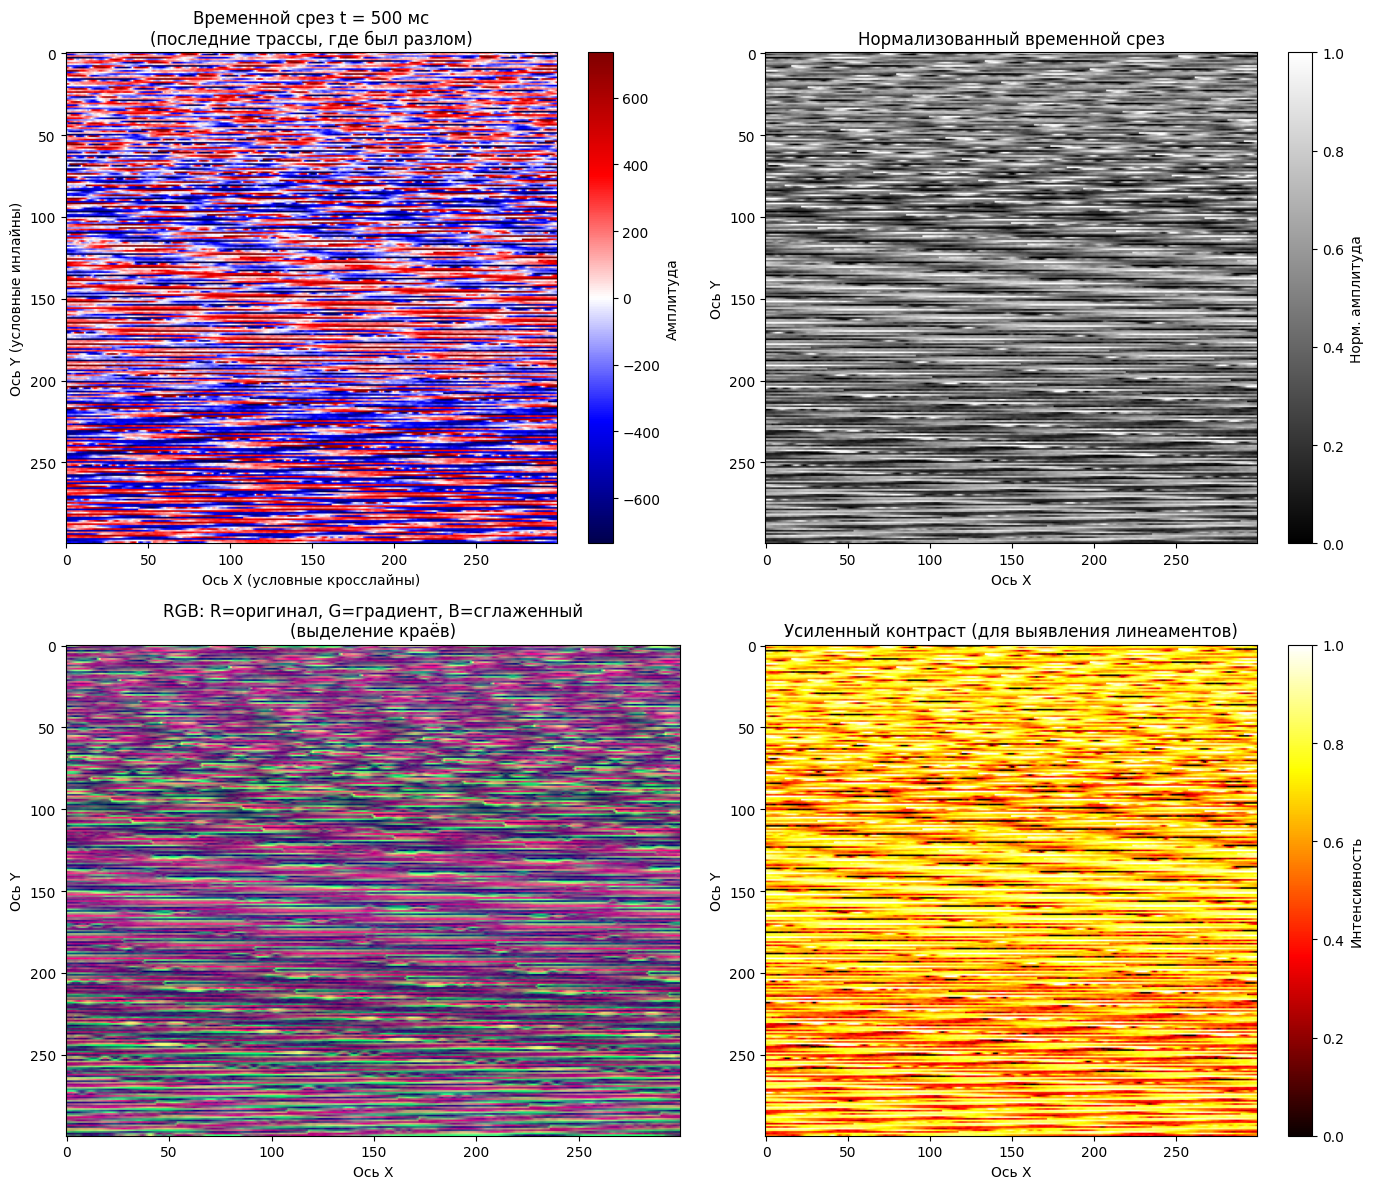


Выделение линеаментов на временном срезе...


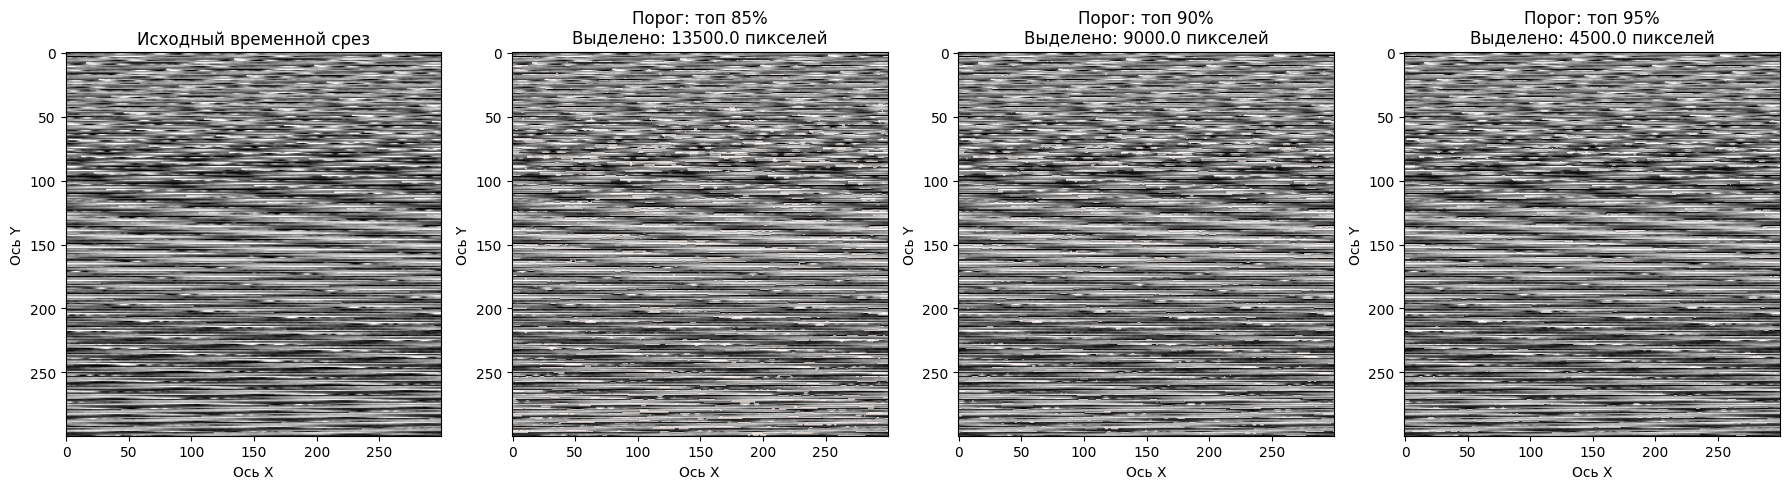


РЕЗУЛЬТАТЫ АНАЛИЗА ВРЕМЕННОГО СРЕЗА

Параметры:
  Временной срез: 500 мс (отсчёт 166)
  Размер среза: 300 × 300 (условные инлайны × кросслайны)
  Метод обработки: PCA

Статистика среза:
  Минимум: -1305.4839
  Максимум: 1155.7842
  Среднее: -39.1978
  Стандартное отклонение: 380.6145

Статистика градиента (края):
  Средний градиент: 1680.3751
  Макс. градиент: 8245.9180

ИНТЕРПРЕТАЦИЯ:
На временном срезе:
  - Линейные/извилистые структуры → палеорусла, каналы или разломы
  - Красные области на последних картинках — автоматически выделенные линеаменты
  - Яркие пятна на усиленном контрасте → аномалии

Сравните с вертикальным разрезом (из предыдущих запусков):
  - Если на вертикальном разрезе был разлом, на горизонтальном срезе
    должна быть линейная аномалия под определённым углом


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import segyio
import os
from scipy.ndimage import gaussian_filter, sobel

# ------------------------------------------------------------------------------
# Параметры
# ------------------------------------------------------------------------------
file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

# Параметры временного среза
time_slice_ms = 500        # время в миллисекундах
n_x = 300                  # размер по оси X (условные "инлайны")
n_y = 300                  # размер по оси Y (условные "кросслайны")
use_last_part = True       # True = последние трассы, False = первые

# Метод обработки: 'pca' или 'fft'
method = 'pca'
# ------------------------------------------------------------------------------

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Файл не найден: {file_path}")

print("="*70)
print("АНАЛИЗ ГОРИЗОНТАЛЬНОГО (ВРЕМЕННОГО) СРЕЗА")
if use_last_part:
    print("На последней части куба (где был большой разлом)")
else:
    print("На первой части куба")
print("="*70)

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("\nЗагрузка данных...")

with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size
    dt = segyfile.bin[segyio.BinField.Interval] / 1000  # интервал в мс

    print(f"  Всего трасс: {n_traces_total}")
    print(f"  Отсчётов на трассу: {n_samples}")
    print(f"  Интервал дискретизации: {dt} мс")

    # Определяем номер временного отсчёта
    time_index = int(time_slice_ms / dt)
    time_index = min(time_index, n_samples - 1)
    print(f"  Временной срез: {time_slice_ms} мс (отсчёт {time_index})")

    # Определяем, сколько трасс нужно для сетки n_x × n_y
    n_traces_needed = n_x * n_y
    if n_traces_needed > n_traces_total:
        # Если не хватает, уменьшаем размеры
        n_x = int(np.sqrt(n_traces_total))
        n_y = n_x
        n_traces_needed = n_x * n_y
        print(f"  Уменьшен размер сетки до {n_x} × {n_y} = {n_traces_needed} трасс")

    # Берём нужные трассы (последние или первые)
    if use_last_part:
        start_idx = n_traces_total - n_traces_needed
        print(f"  Берём последние {n_traces_needed} трасс (с {start_idx} по {n_traces_total-1})")
    else:
        start_idx = 0
        print(f"  Берём первые {n_traces_needed} трасс")

    # Загружаем временной срез для выбранных трасс
    print("\nЗагрузка временного среза...")
    time_slice_1d = np.zeros(n_traces_needed, dtype=np.float32)

    for i in range(n_traces_needed):
        trace_idx = start_idx + i
        time_slice_1d[i] = segyfile.trace[trace_idx][time_index]
        if i % 10000 == 0:
            print(f"  Загружено трасс: {i+1}/{n_traces_needed}")

    # Преобразуем в 2D сетку
    time_slice = time_slice_1d.reshape(n_x, n_y)
    print(f"\n  Размер временного среза: {time_slice.shape}")

# =============================================================================
# 2. ОБРАБОТКА ВРЕМЕННОГО СРЕЗА
# =============================================================================

def normalize(data):
    """Нормализация в диапазон [0,1] с отсечением выбросов"""
    vmin = np.percentile(data, 2)
    vmax = np.percentile(data, 98)
    if vmax - vmin < 1e-9:
        return np.zeros_like(data)
    return np.clip((data - vmin) / (vmax - vmin), 0, 1)

def fft_filter_2d(image, low_cut, high_cut, smooth=0.02):
    """2D БПФ фильтрация (частотная декомпозиция)"""
    fft = np.fft.fft2(image)
    fft_shift = np.fft.fftshift(fft)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - ccol)**2 + (Y - crow)**2) / max(crow, ccol)
    freq_norm = dist / np.sqrt(2) * 0.5

    mask = np.exp(- ((freq_norm - low_cut)**2) / (2 * smooth**2)) - \
           np.exp(- ((freq_norm - high_cut)**2) / (2 * smooth**2))
    mask = np.clip(mask, 0, 1)

    filtered_shift = fft_shift * mask
    filtered = np.fft.ifft2(np.fft.ifftshift(filtered_shift))
    return np.real(filtered)

if method == 'pca':
    print("\n" + "="*50)
    print("МЕТОД: RGB-смешивание (глава 2.2)")
    print("="*50)

    time_slice_norm = normalize(time_slice)

    # Вычисляем градиенты для выделения краёв
    grad_x = np.gradient(time_slice_norm, axis=1)
    grad_y = np.gradient(time_slice_norm, axis=0)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Сглаженная версия
    smoothed = gaussian_filter(time_slice_norm, sigma=5)

    # RGB: R = оригинал, G = градиент, B = сглаженный
    R = time_slice_norm
    G = normalize(grad_magnitude)
    B = smoothed

    rgb_image = np.stack([R, G, B], axis=-1)

elif method == 'fft':
    print("\n" + "="*50)
    print("МЕТОД: Частотная декомпозиция (FFT)")
    print("="*50)

    low = fft_filter_2d(time_slice, 0.00, 0.10)
    mid = fft_filter_2d(time_slice, 0.10, 0.30)
    high = fft_filter_2d(time_slice, 0.30, 0.50)

    R = normalize(low)
    G = normalize(mid)
    B = normalize(high)

    rgb_image = np.stack([R, G, B], axis=-1)

# =============================================================================
# 3. ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Исходный временной срез
ax1 = axes[0, 0]
im1 = ax1.imshow(time_slice, cmap='seismic', aspect='auto',
                 vmin=-np.percentile(np.abs(time_slice), 95),
                 vmax=np.percentile(np.abs(time_slice), 95))
title = f'Временной срез t = {time_slice_ms} мс'
if use_last_part:
    title += '\n(последние трассы, где был разлом)'
else:
    title += '\n(первые трассы)'
ax1.set_title(title, fontsize=12)
ax1.set_xlabel('Ось X (условные кросслайны)')
ax1.set_ylabel('Ось Y (условные инлайны)')
plt.colorbar(im1, ax=ax1, label='Амплитуда')

# Нормализованный срез
ax2 = axes[0, 1]
im2 = ax2.imshow(normalize(time_slice), cmap='gray', aspect='auto')
ax2.set_title('Нормализованный временной срез', fontsize=12)
ax2.set_xlabel('Ось X')
ax2.set_ylabel('Ось Y')
plt.colorbar(im2, ax=ax2, label='Норм. амплитуда')

# RGB-изображение
ax3 = axes[1, 0]
ax3.imshow(rgb_image, aspect='auto')
if method == 'pca':
    ax3.set_title('RGB: R=оригинал, G=градиент, B=сглаженный\n(выделение краёв)', fontsize=12)
else:
    ax3.set_title('RGB: R=низкие, G=средние, B=высокие частоты', fontsize=12)
ax3.set_xlabel('Ось X')
ax3.set_ylabel('Ось Y')

# Усиленный контраст
ax4 = axes[1, 1]
enhanced = normalize(time_slice) ** 0.5
im4 = ax4.imshow(enhanced, cmap='hot', aspect='auto')
ax4.set_title('Усиленный контраст (для выявления линеаментов)', fontsize=12)
ax4.set_xlabel('Ось X')
ax4.set_ylabel('Ось Y')
plt.colorbar(im4, ax=ax4, label='Интенсивность')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ВЫДЕЛЕНИЕ ЛИНЕАМЕНТОВ
# =============================================================================
print("\nВыделение линеаментов на временном срезе...")

# Вычисляем величину градиента
grad_x = sobel(time_slice, axis=1)
grad_y = sobel(time_slice, axis=0)
edge_strength = np.sqrt(grad_x**2 + grad_y**2)
edge_norm = normalize(edge_strength)

# Разные пороги
thresholds = [85, 90, 95]
fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(18, 5))

# Исходный срез
axes[0].imshow(time_slice, cmap='gray', aspect='auto',
               vmin=-np.percentile(np.abs(time_slice), 95),
               vmax=np.percentile(np.abs(time_slice), 95))
axes[0].set_title('Исходный временной срез', fontsize=12)
axes[0].set_xlabel('Ось X')
axes[0].set_ylabel('Ось Y')

# Выделенные линеаменты
for i, thresh_pct in enumerate(thresholds):
    threshold = np.percentile(edge_norm, thresh_pct)
    lineaments = (edge_norm > threshold).astype(float)

    ax = axes[i + 1]
    ax.imshow(time_slice, cmap='gray', aspect='auto',
              vmin=-np.percentile(np.abs(time_slice), 95),
              vmax=np.percentile(np.abs(time_slice), 95))

    masked = np.ma.masked_where(lineaments == 0, lineaments)
    ax.imshow(masked, cmap='Reds', aspect='auto', alpha=0.7)

    ax.set_title(f'Порог: топ {thresh_pct}%\nВыделено: {np.sum(lineaments)} пикселей', fontsize=12)
    ax.set_xlabel('Ось X')
    ax.set_ylabel('Ось Y')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. ВЫВОД ОТЧЁТА
# =============================================================================
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ АНАЛИЗА ВРЕМЕННОГО СРЕЗА")
print("="*70)
print(f"\nПараметры:")
print(f"  Временной срез: {time_slice_ms} мс (отсчёт {time_index})")
print(f"  Размер среза: {n_x} × {n_y} (условные инлайны × кросслайны)")
print(f"  Метод обработки: {method.upper()}")
print(f"\nСтатистика среза:")
print(f"  Минимум: {np.min(time_slice):.4f}")
print(f"  Максимум: {np.max(time_slice):.4f}")
print(f"  Среднее: {np.mean(time_slice):.4f}")
print(f"  Стандартное отклонение: {np.std(time_slice):.4f}")

# Дополнительная статистика по градиенту
print(f"\nСтатистика градиента (края):")
print(f"  Средний градиент: {np.mean(edge_strength):.4f}")
print(f"  Макс. градиент: {np.max(edge_strength):.4f}")

print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ:")
print("="*70)
print("На временном срезе:")
print("  - Линейные/извилистые структуры → палеорусла, каналы или разломы")
print("  - Красные области на последних картинках — автоматически выделенные линеаменты")
print("  - Яркие пятна на усиленном контрасте → аномалии")
print("\nСравните с вертикальным разрезом (из предыдущих запусков):")
print("  - Если на вертикальном разрезе был разлом, на горизонтальном срезе")
print("    должна быть линейная аномалия под определённым углом")
print("="*70)